In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
RAW_DATA_PATH = r"D:\projects\AI-Stock-Analytics-System\data\raw"
PROCESSED_DATA_PATH = r"D:\projects\AI-Stock-Analytics-System\data\processed"

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

In [4]:
csv_files = sorted([
    file for file in os.listdir(RAW_DATA_PATH)
    if file.endswith(".csv")
])

print(f"Total CSV Files Found: {len(csv_files)}")

Total CSV Files Found: 101


In [5]:
all_data = []

for file in csv_files:

    file_path = os.path.join(RAW_DATA_PATH, file)

    df = pd.read_csv(file_path)

    # Add ticker column
    ticker = file.replace(".csv", "")
    df["Ticker"] = ticker

    all_data.append(df)

merged_df = pd.concat(all_data, ignore_index=True)

print("Dataset merged successfully!")

Dataset merged successfully!


In [6]:
merged_df.head()

,Price,Close,High,Low,Open,Volume,Ticker
0,Ticker,ACC.NS,ACC.NS,ACC.NS,ACC.NS,ACC.NS,ACC
1,Date,NaN,NaN,NaN,NaN,NaN,ACC
2,2005-01-03,238.5089569091797,239.4867346073633,236.58831377155087,238.5089569091797,1031091,ACC
3,2005-01-04,245.3185577392578,246.78523522981465,238.29948724625214,239.55662720160976,2377765,ACC
4,2005-01-05,243.43280029296875,250.6614075431996,234.91214096088305,245.1439274001194,3886135,ACC


In [7]:
merged_df.tail()

,Price,Close,High,Low,Open,Volume,Ticker
481768,2026-07-21,1142.07373046875,1148.76778856126,1136.978333506865,1147.069241600151,622323,ZYDUSLIFE
481769,2026-07-22,1125.288818359375,1137.0781507418442,1112.00071076718,1136.978264917386,1619112,ZYDUSLIFE
481770,2026-07-23,1112.800048828125,1127.9863530701155,1105.5065541825356,1118.9944335150835,907148,ZYDUSLIFE
481771,2026-07-24,1108.699951171875,1119.5999755859375,1099.0,1109.0,837032,ZYDUSLIFE
481772,2026-07-27,1108.199951171875,1126.199951171875,1104.4000244140625,1111.9000244140625,607249,ZYDUSLIFE


In [8]:
df = pd.read_csv(os.path.join(RAW_DATA_PATH, csv_files[0]))

print(df.head())

        Price               Close                High                 Low  \
0      Ticker              ACC.NS              ACC.NS              ACC.NS   
1        Date                 NaN                 NaN                 NaN   
2  2005-01-03   238.5089569091797   239.4867346073633  236.58831377155087   
3  2005-01-04   245.3185577392578  246.78523522981465  238.29948724625214   
4  2005-01-05  243.43280029296875   250.6614075431996  234.91214096088305   

                 Open   Volume  
0              ACC.NS   ACC.NS  
1                 NaN      NaN  
2   238.5089569091797  1031091  
3  239.55662720160976  2377765  
4   245.1439274001194  3886135  


In [9]:
df = pd.read_csv(file_path, header=[0, 1])

In [10]:
df.columns = [col[0] for col in df.columns]

In [11]:
df.rename(columns={"Price": "Date"}, inplace=True)
df["Ticker"] = ticker

In [12]:
df = pd.read_csv(os.path.join(RAW_DATA_PATH, csv_files[0]))
print(df.head(5))
print(df.columns)

        Price               Close                High                 Low  \
0      Ticker              ACC.NS              ACC.NS              ACC.NS   
1        Date                 NaN                 NaN                 NaN   
2  2005-01-03   238.5089569091797   239.4867346073633  236.58831377155087   
3  2005-01-04   245.3185577392578  246.78523522981465  238.29948724625214   
4  2005-01-05  243.43280029296875   250.6614075431996  234.91214096088305   

                 Open   Volume  
0              ACC.NS   ACC.NS  
1                 NaN      NaN  
2   238.5089569091797  1031091  
3  239.55662720160976  2377765  
4   245.1439274001194  3886135  
Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [13]:
all_data = []

for file in csv_files:

    file_path = os.path.join(RAW_DATA_PATH, file)

    # Read CSV with two header rows
    df = pd.read_csv(file_path, header=[0, 1])

    # Flatten MultiIndex columns
    df.columns = [col[0] for col in df.columns]

    # Rename first column
    df.rename(columns={"Price": "Date"}, inplace=True)

    # Remove the first row (Ticker metadata)
    df = df.iloc[1:].reset_index(drop=True)

    # Add ticker column
    ticker = file.replace(".csv", "")
    df["Ticker"] = ticker

    all_data.append(df)

merged_df = pd.concat(all_data, ignore_index=True)

print("Merged Successfully!")

Merged Successfully!


In [14]:
merged_df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,238.508957,239.486735,236.588314,238.508957,1031091.0,ACC
1,2005-01-04,245.318558,246.785235,238.299487,239.556627,2377765.0,ACC
2,2005-01-05,243.432800,250.661408,234.912141,245.143927,3886135.0,ACC
3,2005-01-06,239.975601,248.915312,237.461301,243.048626,2954242.0,ACC
4,2005-01-07,244.794708,247.797887,240.255006,247.797887,1817394.0,ACC


In [15]:
merged_df.tail()

,Date,Close,High,Low,Open,Volume,Ticker
481566,2026-07-21,1142.073730,1148.767789,1136.978334,1147.069242,622323.0,ZYDUSLIFE
481567,2026-07-22,1125.288818,1137.078151,1112.000711,1136.978265,1619112.0,ZYDUSLIFE
481568,2026-07-23,1112.800049,1127.986353,1105.506554,1118.994434,907148.0,ZYDUSLIFE
481569,2026-07-24,1108.699951,1119.599976,1099.000000,1109.000000,837032.0,ZYDUSLIFE
481570,2026-07-27,1108.199951,1126.199951,1104.400024,1111.900024,607249.0,ZYDUSLIFE


In [16]:
merged_df.shape

(481571, 7)

In [17]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481571 entries, 0 to 481570
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    481571 non-null  object 
 1   Close   481533 non-null  float64
 2   High    481533 non-null  float64
 3   Low     481533 non-null  float64
 4   Open    481533 non-null  float64
 5   Volume  481571 non-null  float64
 6   Ticker  481571 non-null  object 
dtypes: float64(5), object(2)
memory usage: 25.7+ MB


In [18]:
merged_df.isnull().sum()

Date       0
Close     38
High      38
Low       38
Open      38
Volume     0
Ticker     0
dtype: int64

In [19]:
merged_df.duplicated().sum()

np.int64(0)

In [20]:
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

merged_df[numeric_columns] = merged_df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

In [21]:
merged_df.dtypes

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume           float64
Ticker            object
dtype: object

In [22]:
print("Start Date :", merged_df["Date"].min())
print("End Date   :", merged_df["Date"].max())

Start Date : 2005-01-03 00:00:00
End Date   : 2026-07-27 00:00:00


In [23]:
print("Total Stocks :", merged_df["Ticker"].nunique())

Total Stocks : 101


In [24]:
merged_df.to_csv(
    os.path.join(PROCESSED_DATA_PATH, "cleaned_stock_data.csv"),
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


eda

In [26]:
merged_df.describe()

,Date,Close,High,Low,Open,Volume
count,481571,481533.000000,481533.000000,481533.000000,481533.000000,4.815710e+05
mean,2016-05-22 05:33:46.774037504,889.078224,901.089202,877.703649,889.828766,9.383867e+06
min,2005-01-03 00:00:00,0.413098,0.439512,0.391880,0.407036,0.000000e+00
25%,2011-03-22 00:00:00,69.029778,70.348969,67.838731,69.123976,6.627370e+05
50%,2016-08-12 00:00:00,198.491547,201.847048,195.390512,198.699466,2.577472e+06
75%,2021-10-01 00:00:00,692.183228,702.451314,683.199480,693.106120,8.351580e+06
max,2026-07-27 00:00:00,42240.000000,42985.000000,41720.000000,42325.000000,1.807991e+09
std,NaN,2622.871741,2656.256887,2591.357830,2625.235337,3.135045e+07


In [27]:
missing_rows = merged_df[merged_df.isnull().any(axis=1)]

missing_rows

,Date,Close,High,Low,Open,Volume,Ticker
5324,2026-07-27,NaN,NaN,NaN,NaN,110429.0,ACC
38023,2026-07-27,NaN,NaN,NaN,NaN,2643437.0,AXISBANK
43348,2026-07-27,NaN,NaN,NaN,NaN,117250.0,BAJAJ-AUTO
48672,2026-07-27,NaN,NaN,NaN,NaN,571292.0,BAJAJFINSV
59054,2026-07-27,NaN,NaN,NaN,NaN,41318.0,BALKRISIND
85678,2026-07-27,NaN,NaN,NaN,NaN,9164.0,BOSCHLTD
91003,2026-07-27,NaN,NaN,NaN,NaN,2738143.0,BPCL
96328,2026-07-27,NaN,NaN,NaN,NaN,170402.0,BRITANNIA
112303,2026-07-27,NaN,NaN,NaN,NaN,933091.0,CIPLA
126833,2026-07-27,NaN,NaN,NaN,NaN,202308.0,COLPAL


In [28]:
missing_rows = merged_df[merged_df.isnull().any(axis=1)]

print(missing_rows[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]])

             Date      Ticker  Open  High  Low  Close     Volume
5324   2026-07-27         ACC   NaN   NaN  NaN    NaN   110429.0
38023  2026-07-27    AXISBANK   NaN   NaN  NaN    NaN  2643437.0
43348  2026-07-27  BAJAJ-AUTO   NaN   NaN  NaN    NaN   117250.0
48672  2026-07-27  BAJAJFINSV   NaN   NaN  NaN    NaN   571292.0
59054  2026-07-27  BALKRISIND   NaN   NaN  NaN    NaN    41318.0
85678  2026-07-27    BOSCHLTD   NaN   NaN  NaN    NaN     9164.0
91003  2026-07-27        BPCL   NaN   NaN  NaN    NaN  2738143.0
96328  2026-07-27   BRITANNIA   NaN   NaN  NaN    NaN   170402.0
112303 2026-07-27       CIPLA   NaN   NaN  NaN    NaN   933091.0
126833 2026-07-27      COLPAL   NaN   NaN  NaN    NaN   202308.0
137483 2026-07-27       DABUR   NaN   NaN  NaN    NaN  2899375.0
147510 2026-07-27         DLF   NaN   NaN  NaN    NaN  2964638.0
155148 2026-07-27     DRREDDY   NaN   NaN  NaN    NaN   889485.0
167039 2026-07-27        GAIL   NaN   NaN  NaN    NaN  6724728.0
177689 2026-07-27      GR

In [29]:
merged_df = merged_df.dropna().reset_index(drop=True)

print(merged_df.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64


In [30]:
merged_df.to_csv(
    os.path.join(PROCESSED_DATA_PATH, "cleaned_stock_data.csv"),
    index=False
)

In [33]:
stock_counts = merged_df["Ticker"].value_counts()

print(stock_counts.head())

Ticker
HCLTECH       5326
BAJFINANCE    5325
BANKBARODA    5325
ASHOKLEY      5325
AMBUJACEM     5325
Name: count, dtype: int64


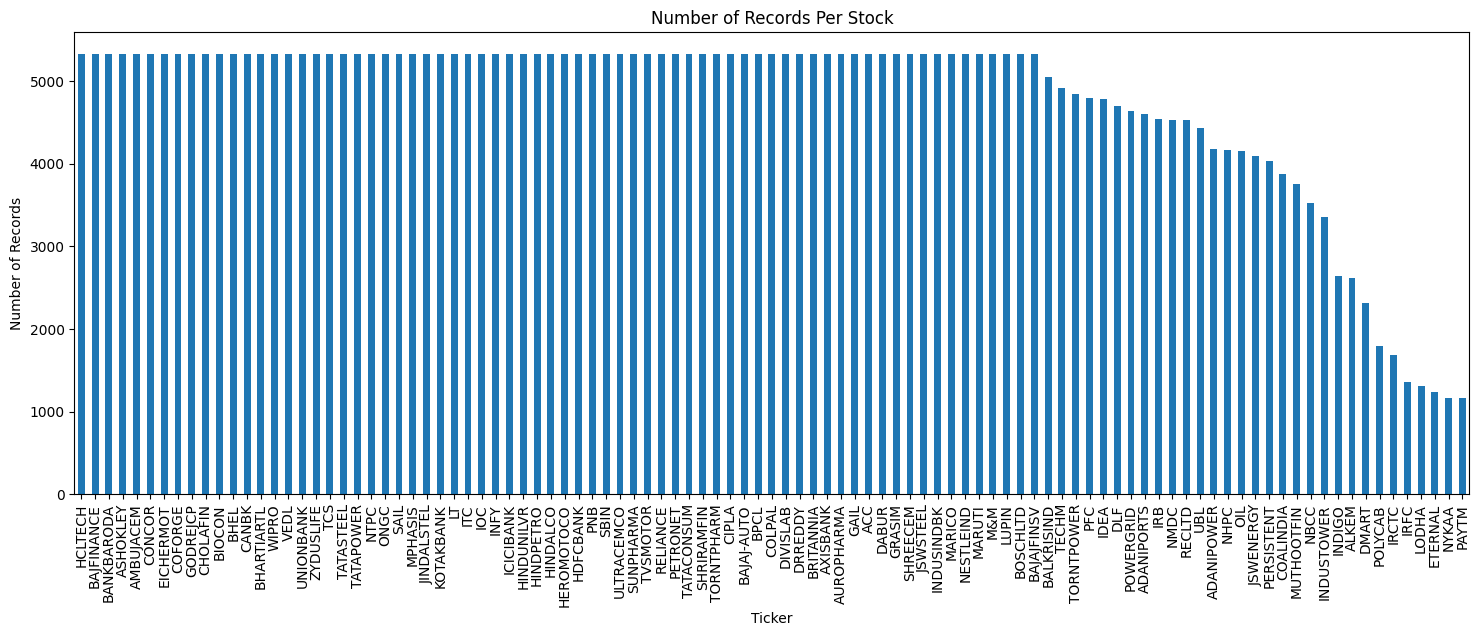

In [34]:
plt.figure(figsize=(18,6))

stock_counts.plot(kind="bar")

plt.title("Number of Records Per Stock")
plt.xlabel("Ticker")
plt.ylabel("Number of Records")

plt.show()

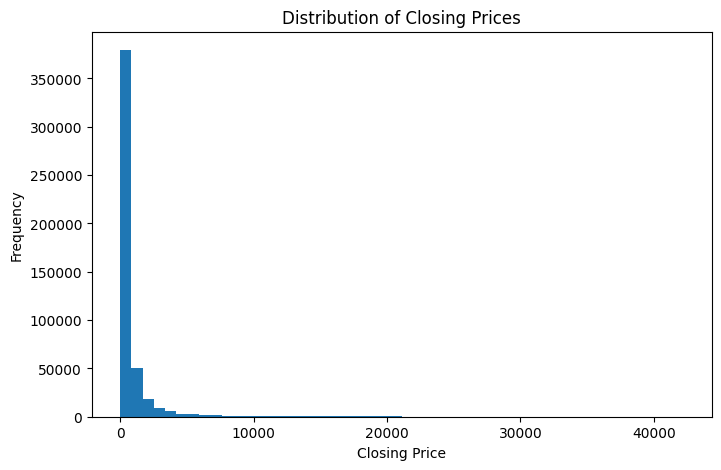

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    merged_df["Close"],
    bins=50
)

plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

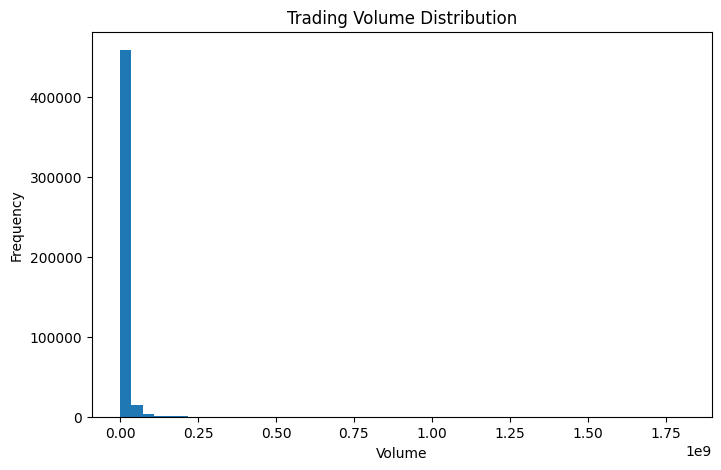

In [36]:
plt.figure(figsize=(8,5))

plt.hist(
    merged_df["Volume"],
    bins=50
)

plt.title("Trading Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

In [37]:
corr = merged_df[
    ["Open","High","Low","Close","Volume"]
].corr()

corr

,Open,High,Low,Close,Volume
Open,1.000000,0.999917,0.999925,0.999856,-0.080851
High,0.999917,1.000000,0.999894,0.999939,-0.080810
Low,0.999925,0.999894,1.000000,0.999931,-0.080871
Close,0.999856,0.999939,0.999931,1.000000,-0.080829
Volume,-0.080851,-0.080810,-0.080871,-0.080829,1.000000


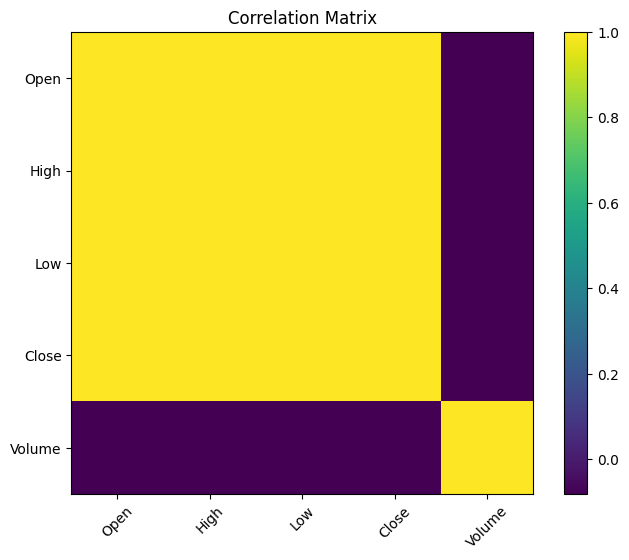

In [38]:
plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

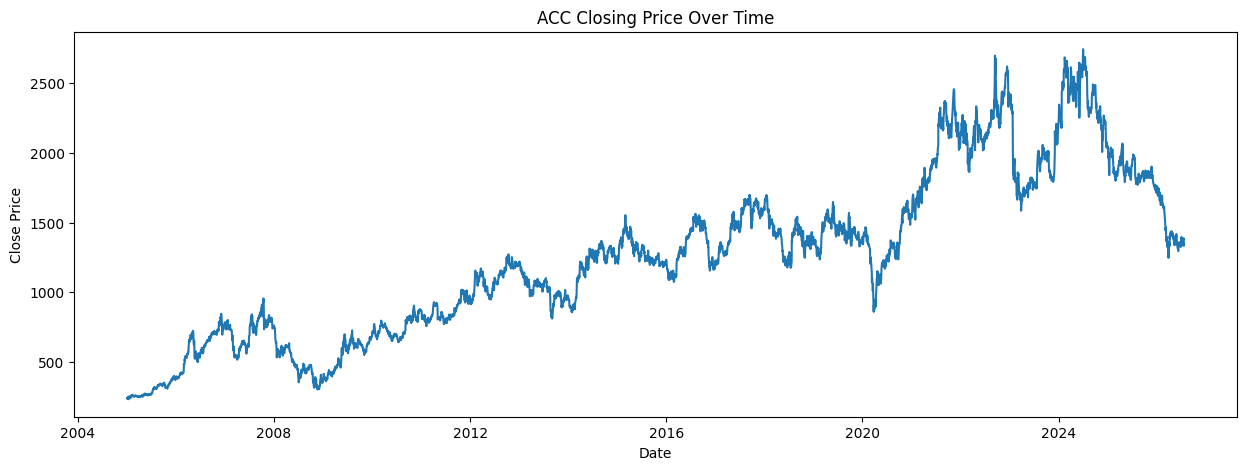

In [39]:
acc = merged_df[
    merged_df["Ticker"]=="ACC"
]

plt.figure(figsize=(15,5))

plt.plot(
    acc["Date"],
    acc["Close"]
)

plt.title("ACC Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

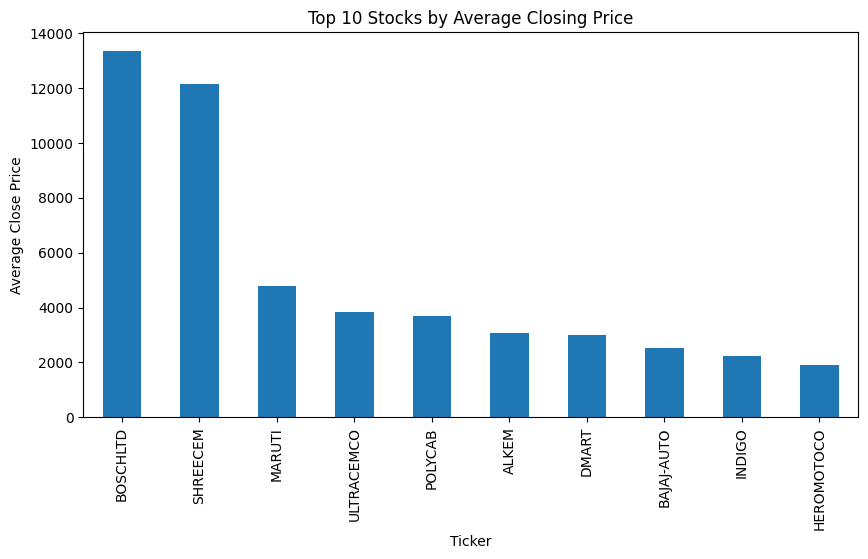

In [40]:
top_price = (
    merged_df.groupby("Ticker")["Close"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_price.plot(kind="bar")

plt.title("Top 10 Stocks by Average Closing Price")
plt.ylabel("Average Close Price")

plt.show()

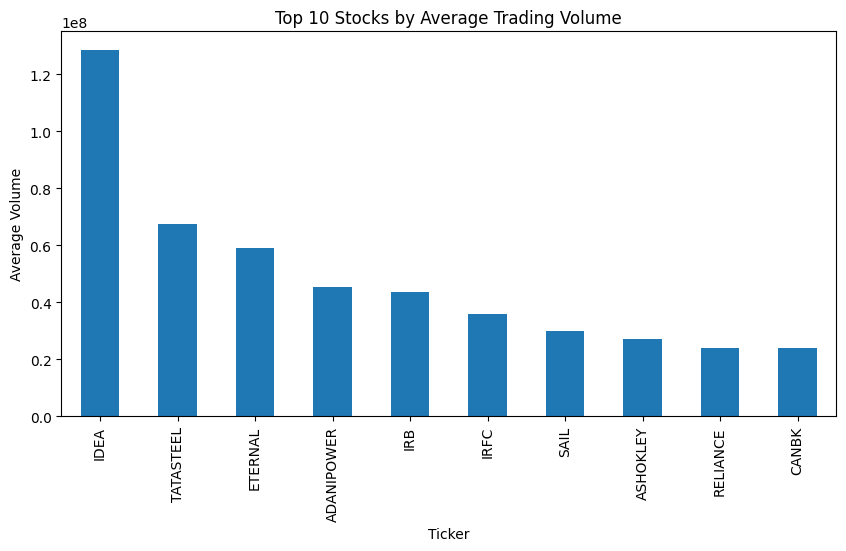

In [41]:
top_volume = (
    merged_df.groupby("Ticker")["Volume"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_volume.plot(kind="bar")

plt.title("Top 10 Stocks by Average Trading Volume")
plt.ylabel("Average Volume")

plt.show()

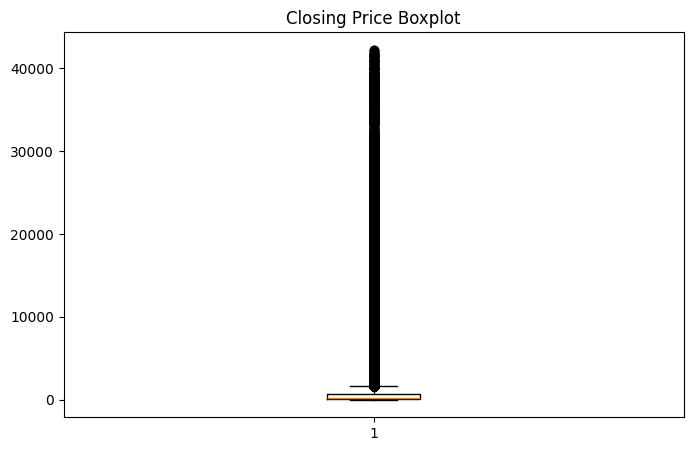

In [42]:
plt.figure(figsize=(8,5))

plt.boxplot(
    merged_df["Close"]
)

plt.title("Closing Price Boxplot")

plt.show()

In [43]:
date_range = merged_df.groupby("Ticker")["Date"].agg(["min", "max"])

date_range.head(10)

,min,max
Ticker,,
ACC,2005-01-03,2026-07-24
ADANIPORTS,2007-11-27,2026-07-27
ADANIPOWER,2009-08-20,2026-07-27
ALKEM,2015-12-23,2026-07-27
AMBUJACEM,2005-01-03,2026-07-27
ASHOKLEY,2005-01-03,2026-07-27
AUROPHARMA,2005-01-03,2026-07-27
AXISBANK,2005-01-03,2026-07-24
BAJAJ-AUTO,2005-01-03,2026-07-24


In [44]:
merged_df.to_csv(
    os.path.join(PROCESSED_DATA_PATH, "cleaned_stock_data.csv"),
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
